# TP - Régression avec Réseaux de Neurones

**Objectif :** Mettre en place un réseau de neurones pour la régression et comparer ses performances avec d'autres méthodes.

## Imports des bibliothèques

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Génération des données initiales

Nous allons générer N=100 données aléatoires de dimension 2 selon la formule :
$$y = 2x + 1 + \text{bruit}$$

In [6]:
# Génération des données
N = 100
x = np.random.rand(N, 1)
y = 2 * x + 1 + 0.1 * np.random.randn(N, 1)

## Visualisation des données

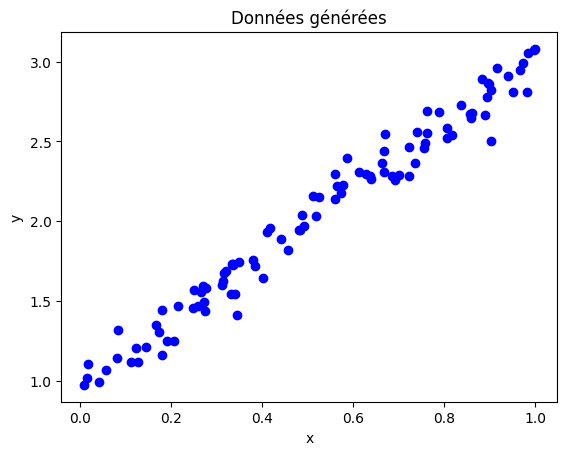

In [7]:
plt.scatter(x, y, color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Données générées')
plt.show()

## Division des données (train/test)

Répartir les données en **80% pour l'entraînement** et **20% pour le test**.

In [8]:
# Division des données en 80% train et 20% test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Données d'entraînement : {x_train.shape}")
print(f"Données de test : {x_test.shape}")

Données d'entraînement : (80, 1)
Données de test : (20, 1)


---
## Question 1 : Implémentation du réseau de neurones de base

Compléter l'implémentation d'un réseau de neurones comprenant :
- Une couche d'entrée
- Une couche cachée avec **2 neurones** (à compléter)
- Une couche de sortie (à compléter)

Il faut également choisir une **fonction de coût adaptée à la régression**.

In [9]:
# Créer le modèle de réseau de neurones
model = keras.Sequential([
    layers.Input(shape=(1,)),
    # Couche cachée avec 2 neurones et activation ReLU
    layers.Dense(2, activation='relu'),
    
    # Couche de sortie (1 neurone pour la régression)
    layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compiler le modèle avec une fonction de coût adaptée à la régression
# Pour la régression, on utilise 'mean_squared_error' (MSE)
model.compile(optimizer='adam', loss='mean_squared_error')

### Entraînement du modèle

In [11]:
# Entraîner le modèle
Nb_epochs = 80
Batchsize = 32
history = model.fit(x_train, y_train, epochs=Nb_epochs, batch_size=Batchsize, 
                    validation_data=(x_test, y_test), verbose=1)

Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 5.0476 - val_loss: 5.7929
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 5.0476 - val_loss: 5.7929
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.0173 - val_loss: 5.7599
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.0173 - val_loss: 5.7599
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9879 - val_loss: 5.7270
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9879 - val_loss: 5.7270
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9587 - val_loss: 5.6944
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9587 - val_loss: 5.6944
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.9299 - val_loss: 5.6622
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.9299 - val_loss: 5.6622
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9005 - val_loss: 5.6304
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9005 - val_loss: 5.6304
Epoc

### Évaluation sur les données de test

In [12]:
# Faire des prédictions et calculer le MSE
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE sur les données de test : {mse:.4f}")

# Évaluation directe avec le modèle
test_loss = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss (MSE) : {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
MSE sur les données de test : 4.1089
Test Loss (MSE) : 4.1089
MSE sur les données de test : 4.1089
Test Loss (MSE) : 4.1089


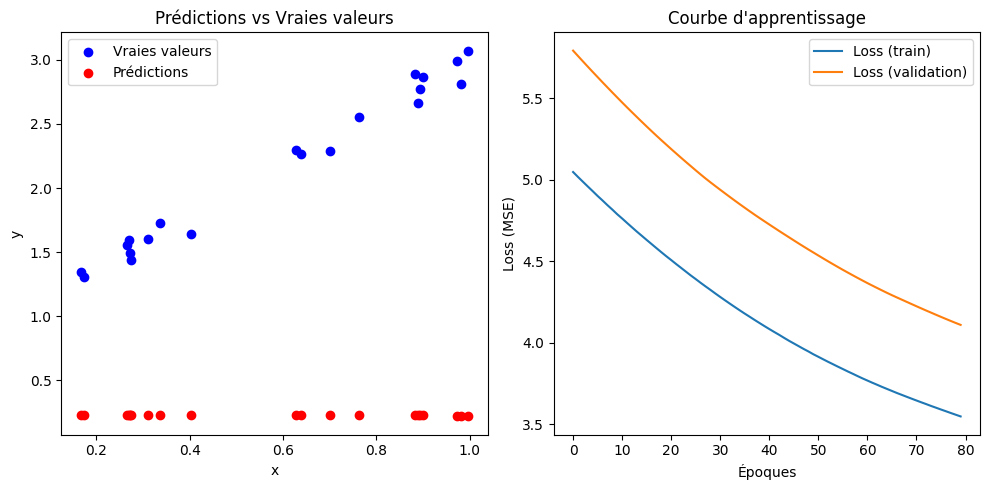

In [13]:
# Visualisation des prédictions
plt.figure(figsize=(10, 5))

# Graphique 1 : Prédictions vs Vraies valeurs
plt.subplot(1, 2, 1)
plt.scatter(x_test, y_test, color='blue', label='Vraies valeurs')
plt.scatter(x_test, y_pred, color='red', label='Prédictions')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Prédictions vs Vraies valeurs')
plt.legend()

# Graphique 2 : Courbe d'apprentissage
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (validation)')
plt.xlabel('Époques')
plt.ylabel('Loss (MSE)')
plt.title('Courbe d\'apprentissage')
plt.legend()

plt.tight_layout()
plt.show()

---
## Question 2 : Test de différentes configurations

### Question 2a : Nombre de couches cachées

Tester plusieurs architectures en variant le **nombre de couches cachées**.

In [14]:
# Tester différents nombres de couches cachées
# Exemple : 1 couche, 2 couches, 3 couches
results_layers = {}

# Configuration : [nombre de neurones par couche]
configs = {
    '1 couche': [10],
    '2 couches': [10, 5],
    '3 couches': [10, 5, 3]
}

for name, layers_config in configs.items():
    # Créer le modèle
    model_temp = keras.Sequential([layers.Input(shape=(1,))])
    for neurons in layers_config:
        model_temp.add(layers.Dense(neurons, activation='relu'))
    model_temp.add(layers.Dense(1))
    
    # Compiler et entraîner
    model_temp.compile(optimizer='adam', loss='mean_squared_error')
    model_temp.fit(x_train, y_train, epochs=80, batch_size=32, verbose=0)
    
    # Évaluer
    y_pred_temp = model_temp.predict(x_test, verbose=0)
    mse_temp = mean_squared_error(y_test, y_pred_temp)
    results_layers[name] = mse_temp
    print(f"{name} : MSE = {mse_temp:.4f}")

print("\nMeilleure configuration :", min(results_layers, key=results_layers.get))

1 couche : MSE = 2.1756
2 couches : MSE = 0.2950
2 couches : MSE = 0.2950
3 couches : MSE = 0.0309

Meilleure configuration : 3 couches
3 couches : MSE = 0.0309

Meilleure configuration : 3 couches


### Question 2b : Nombre de neurones

Tester plusieurs architectures en variant le **nombre de neurones par couche**.

In [15]:
# Tester différents nombres de neurones
# Exemple : 2, 5, 10, 20 neurones
results_neurons = {}

neurons_list = [2, 5, 10, 20, 50]

for n_neurons in neurons_list:
    # Créer le modèle
    model_temp = keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(n_neurons, activation='relu'),
        layers.Dense(1)
    ])
    
    # Compiler et entraîner
    model_temp.compile(optimizer='adam', loss='mean_squared_error')
    model_temp.fit(x_train, y_train, epochs=80, batch_size=32, verbose=0)
    
    # Évaluer
    y_pred_temp = model_temp.predict(x_test, verbose=0)
    mse_temp = mean_squared_error(y_test, y_pred_temp)
    results_neurons[f'{n_neurons} neurones'] = mse_temp
    print(f"{n_neurons} neurones : MSE = {mse_temp:.4f}")

print("\nMeilleure configuration :", min(results_neurons, key=results_neurons.get))

2 neurones : MSE = 5.1205
2 neurones : MSE = 5.1205
5 neurones : MSE = 4.0207
5 neurones : MSE = 4.0207
10 neurones : MSE = 1.8461
10 neurones : MSE = 1.8461
20 neurones : MSE = 0.1846
20 neurones : MSE = 0.1846
50 neurones : MSE = 0.0246

Meilleure configuration : 50 neurones
50 neurones : MSE = 0.0246

Meilleure configuration : 50 neurones


### Question 2c : Paramètres d'optimisation

Tester plusieurs configurations en variant les **paramètres d'optimisation** (learning rate, optimiseur, nombre d'époques, etc.).

In [16]:
# Tester différents paramètres d'optimisation
results_optim = {}

# Test de différents optimiseurs
optimizers = ['adam', 'sgd', 'rmsprop']

for opt in optimizers:
    # Créer le modèle
    model_temp = keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(10, activation='relu'),
        layers.Dense(1)
    ])
    
    # Compiler et entraîner
    model_temp.compile(optimizer=opt, loss='mean_squared_error')
    model_temp.fit(x_train, y_train, epochs=80, batch_size=32, verbose=0)
    
    # Évaluer
    y_pred_temp = model_temp.predict(x_test, verbose=0)
    mse_temp = mean_squared_error(y_test, y_pred_temp)
    results_optim[f'Optimiseur: {opt}'] = mse_temp
    print(f"Optimiseur {opt} : MSE = {mse_temp:.4f}")

# Test de différents learning rates avec Adam
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:
    # Créer le modèle
    model_temp = keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(10, activation='relu'),
        layers.Dense(1)
    ])
    
    # Compiler et entraîner
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model_temp.compile(optimizer=optimizer, loss='mean_squared_error')
    model_temp.fit(x_train, y_train, epochs=80, batch_size=32, verbose=0)
    
    # Évaluer
    y_pred_temp = model_temp.predict(x_test, verbose=0)
    mse_temp = mean_squared_error(y_test, y_pred_temp)
    results_optim[f'LR: {lr}'] = mse_temp
    print(f"Learning rate {lr} : MSE = {mse_temp:.4f}")

print("\nMeilleure configuration :", min(results_optim, key=results_optim.get))

Optimiseur adam : MSE = 1.2411
Optimiseur sgd : MSE = 0.0241
Optimiseur sgd : MSE = 0.0241
Optimiseur rmsprop : MSE = 0.1457
Optimiseur rmsprop : MSE = 0.1457
Learning rate 0.001 : MSE = 0.6447
Learning rate 0.001 : MSE = 0.6447
Learning rate 0.01 : MSE = 0.0086
Learning rate 0.01 : MSE = 0.0086
Learning rate 0.1 : MSE = 0.0063

Meilleure configuration : LR: 0.1
Learning rate 0.1 : MSE = 0.0063

Meilleure configuration : LR: 0.1


---
## Question 3 : Comparaison avec régression linéaire et polynomiale

### Génération d'un nouveau jeu de données

In [17]:
# Génération d'un nouveau jeu de données
N2 = 100
x2 = np.random.rand(N2, 1)
y2 = 2 * x2 + 1 + 0.1 * np.random.randn(N2, 1)

# Division train/test
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

### Entraînement du meilleur modèle de réseau de neurones

Réentraîner votre meilleur modèle de la Question 2 sur ce nouveau jeu de données.

In [18]:
# Créer et entraîner le meilleur modèle (basé sur les résultats précédents)
best_model = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(10, activation='relu'),
    layers.Dense(5, activation='relu'),
    layers.Dense(1)
])

best_model.compile(optimizer='adam', loss='mean_squared_error')
best_model.fit(x2_train, y2_train, epochs=100, batch_size=32, verbose=0)

y_pred_nn = best_model.predict(x2_test, verbose=0)
mse_nn = mean_squared_error(y2_test, y_pred_nn)
print(f"MSE Réseau de neurones : {mse_nn:.4f}")

MSE Réseau de neurones : 0.0611


### Régression linéaire

In [19]:
# Régression linéaire
model_linear = LinearRegression()
model_linear.fit(x2_train, y2_train)
y_pred_linear = model_linear.predict(x2_test)
mse_linear = mean_squared_error(y2_test, y_pred_linear)
print(f"MSE Régression linéaire : {mse_linear:.4f}")

MSE Régression linéaire : 0.0116


### Régression polynomiale (degré 3)

In [20]:
# Régression polynomiale de degré 3
poly_features = PolynomialFeatures(degree=3)
x2_train_poly = poly_features.fit_transform(x2_train)
x2_test_poly = poly_features.transform(x2_test)

model_poly = LinearRegression()
model_poly.fit(x2_train_poly, y2_train)
y_pred_poly = model_poly.predict(x2_test_poly)
mse_poly = mean_squared_error(y2_test, y_pred_poly)
print(f"MSE Régression polynomiale : {mse_poly:.4f}")

MSE Régression polynomiale : 0.0110


### Comparaison des modèles (MSE)

In [21]:
# Comparaison des MSE
print("=== Comparaison des modèles ===")
print(f"MSE Réseau de neurones : {mse_nn:.4f}")
print(f"MSE Régression linéaire : {mse_linear:.4f}")
print(f"MSE Régression polynomiale : {mse_poly:.4f}")

# Trouver le meilleur modèle
mse_dict = {
    'Réseau de neurones': mse_nn,
    'Régression linéaire': mse_linear,
    'Régression polynomiale': mse_poly
}
best = min(mse_dict, key=mse_dict.get)
print(f"\n✓ Meilleur modèle : {best} (MSE = {mse_dict[best]:.4f})")

=== Comparaison des modèles ===
MSE Réseau de neurones : 0.0611
MSE Régression linéaire : 0.0116
MSE Régression polynomiale : 0.0110

✓ Meilleur modèle : Régression polynomiale (MSE = 0.0110)


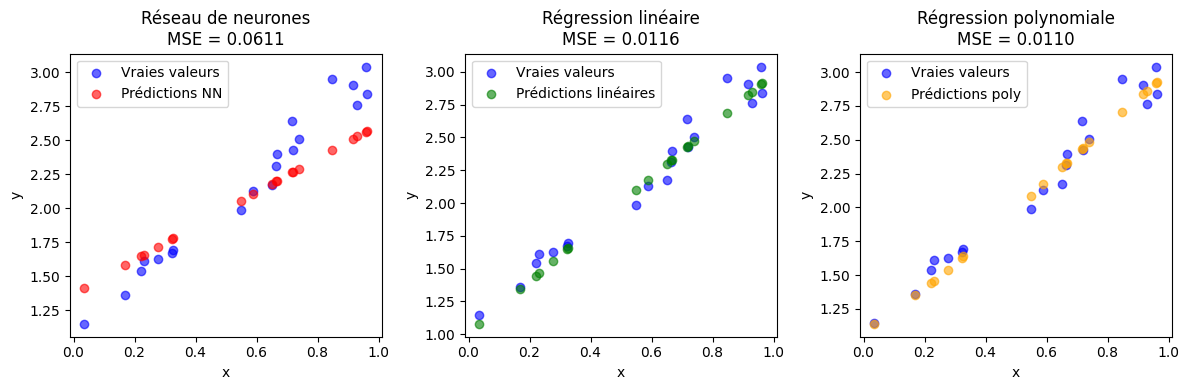

In [22]:
# Visualisation comparative
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(x2_test, y2_test, color='blue', label='Vraies valeurs', alpha=0.6)
plt.scatter(x2_test, y_pred_nn, color='red', label='Prédictions NN', alpha=0.6)
plt.title(f'Réseau de neurones\nMSE = {mse_nn:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(x2_test, y2_test, color='blue', label='Vraies valeurs', alpha=0.6)
plt.scatter(x2_test, y_pred_linear, color='green', label='Prédictions linéaires', alpha=0.6)
plt.title(f'Régression linéaire\nMSE = {mse_linear:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(x2_test, y2_test, color='blue', label='Vraies valeurs', alpha=0.6)
plt.scatter(x2_test, y_pred_poly, color='orange', label='Prédictions poly', alpha=0.6)
plt.title(f'Régression polynomiale\nMSE = {mse_poly:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

---
## Question 4 : Données sinusoïdales

### Génération des données sinusoïdales

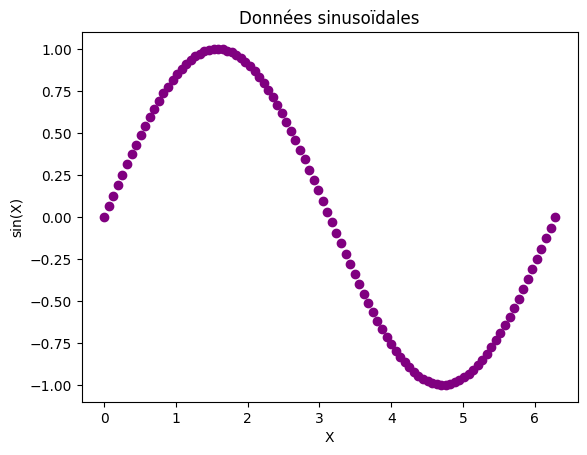

In [23]:
# Génération des données sinusoïdales
X_sin = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_sin = np.sin(X_sin)

# Visualisation
plt.scatter(X_sin, y_sin, color='purple')
plt.xlabel('X')
plt.ylabel('sin(X)')
plt.title('Données sinusoïdales')
plt.show()

In [24]:
# Division train/test des données sinusoïdales
X_sin_train, X_sin_test, y_sin_train, y_sin_test = train_test_split(X_sin, y_sin, test_size=0.2, random_state=42)

### Application du réseau de neurones sur les données sinusoïdales

In [25]:
# Créer et entraîner un réseau de neurones sur les données sinusoïdales
# Pour des données non-linéaires, on utilise plus de neurones
model_sin_nn = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1)
])

model_sin_nn.compile(optimizer='adam', loss='mean_squared_error')
model_sin_nn.fit(X_sin_train, y_sin_train, epochs=150, batch_size=16, verbose=0)

y_pred_sin_nn = model_sin_nn.predict(X_sin_test, verbose=0)
mse_sin_nn = mean_squared_error(y_sin_test, y_pred_sin_nn)
print(f"MSE NN (sinusoïde) : {mse_sin_nn:.6f}")

MSE NN (sinusoïde) : 0.060677


### Application de la régression linéaire sur les données sinusoïdales

In [26]:
# Régression linéaire sur les données sinusoïdales
model_sin_linear = LinearRegression()
model_sin_linear.fit(X_sin_train, y_sin_train)
y_pred_sin_linear = model_sin_linear.predict(X_sin_test)
mse_sin_linear = mean_squared_error(y_sin_test, y_pred_sin_linear)
print(f"MSE Linéaire (sinusoïde) : {mse_sin_linear:.6f}")

MSE Linéaire (sinusoïde) : 0.213375


### Application de la régression polynomiale sur les données sinusoïdales

In [27]:
# Régression polynomiale de degré 3 sur les données sinusoïdales
poly_features_sin = PolynomialFeatures(degree=3)
X_sin_train_poly = poly_features_sin.fit_transform(X_sin_train)
X_sin_test_poly = poly_features_sin.transform(X_sin_test)

model_sin_poly = LinearRegression()
model_sin_poly.fit(X_sin_train_poly, y_sin_train)
y_pred_sin_poly = model_sin_poly.predict(X_sin_test_poly)
mse_sin_poly = mean_squared_error(y_sin_test, y_pred_sin_poly)
print(f"MSE Polynomiale (sinusoïde) : {mse_sin_poly:.6f}")

MSE Polynomiale (sinusoïde) : 0.005350


### Comparaison finale des performances sur les données sinusoïdales

In [28]:
# Comparaison des MSE sur données sinusoïdales
print("=== Comparaison sur données sinusoïdales ===")
print(f"MSE Réseau de neurones : {mse_sin_nn:.6f}")
print(f"MSE Régression linéaire : {mse_sin_linear:.6f}")
print(f"MSE Régression polynomiale : {mse_sin_poly:.6f}")

# Trouver le meilleur modèle
mse_sin_dict = {
    'Réseau de neurones': mse_sin_nn,
    'Régression linéaire': mse_sin_linear,
    'Régression polynomiale': mse_sin_poly
}
best_sin = min(mse_sin_dict, key=mse_sin_dict.get)
print(f"\n✓ Meilleur modèle : {best_sin} (MSE = {mse_sin_dict[best_sin]:.6f})")

=== Comparaison sur données sinusoïdales ===
MSE Réseau de neurones : 0.060677
MSE Régression linéaire : 0.213375
MSE Régression polynomiale : 0.005350

✓ Meilleur modèle : Régression polynomiale (MSE = 0.005350)


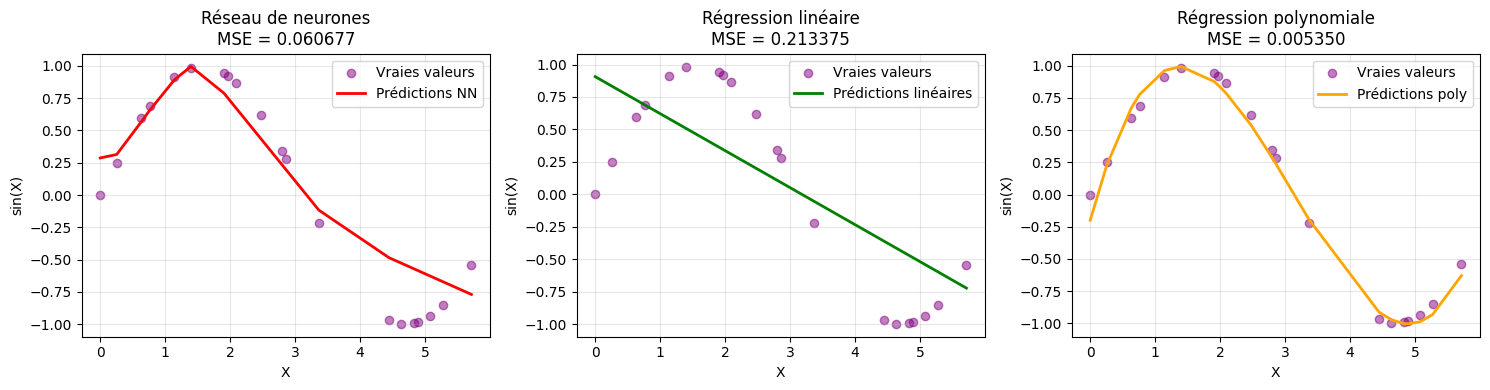

In [29]:
# Visualisation finale comparative sur données sinusoïdales
plt.figure(figsize=(15, 4))

# Trier pour une meilleure visualisation
indices = np.argsort(X_sin_test.flatten())
X_sorted = X_sin_test[indices]
y_test_sorted = y_sin_test[indices]

plt.subplot(1, 3, 1)
plt.scatter(X_sin_test, y_sin_test, color='purple', alpha=0.5, label='Vraies valeurs')
plt.plot(X_sorted, y_pred_sin_nn[indices], color='red', linewidth=2, label='Prédictions NN')
plt.title(f'Réseau de neurones\nMSE = {mse_sin_nn:.6f}')
plt.xlabel('X')
plt.ylabel('sin(X)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_sin_test, y_sin_test, color='purple', alpha=0.5, label='Vraies valeurs')
plt.plot(X_sorted, y_pred_sin_linear[indices], color='green', linewidth=2, label='Prédictions linéaires')
plt.title(f'Régression linéaire\nMSE = {mse_sin_linear:.6f}')
plt.xlabel('X')
plt.ylabel('sin(X)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(X_sin_test, y_sin_test, color='purple', alpha=0.5, label='Vraies valeurs')
plt.plot(X_sorted, y_pred_sin_poly[indices], color='orange', linewidth=2, label='Prédictions poly')
plt.title(f'Régression polynomiale\nMSE = {mse_sin_poly:.6f}')
plt.xlabel('X')
plt.ylabel('sin(X)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()